In [1]:
import matplotlib.pyplot as plt 
import agama
import numpy as np 
import hunter2024mwmodel
import barframe
agama.setUnits(length=1,mass=1,velocity=1)

In [2]:
pot = hunter2024mwmodel.mw_model()
omega = -37.5

In [3]:
xL1 = barframe.xL1(pot, omega)
EL1 = barframe.pot_eff(pot, omega, np.array([xL1, 0.0, 0.0]))
E0 = barframe.pot_eff(pot, omega, np.array([0.0, 0.0, 0.0]))

Ej = (49.0 / 50.0) * (EL1 - E0) + E0
xmax = float(barframe.xmaximum_within_bar(pot, omega, Ej))
tolerance = 1e-3

xs = np.linspace(-(1 - tolerance) * xmax, (1 - tolerance) * xmax, 501)
vxs = barframe.vx_zero_velocity_curve(xs, pot, omega, Ej)

xs_poly = np.concatenate((xs, xs[::-1], [xs[0]]))
vxs_poly = np.concatenate((vxs, -vxs[::-1], [vxs[0]]))


In [60]:
initconds = barframe.sample_initial_conditions_allowed_within_bar(
    pot, omega, Ej, norbits=1,seed=12
)

time_integration = 1e3 * np.sqrt(np.abs(xL1**2 / Ej))

orbits, lyapunov = agama.orbit(
    ic=initconds,
    potential=pot,
    Omega=omega,
    time=time_integration,
    trajsize=int(1e3),
    lyapunov=True,
    separateTime=True,
    dtype=object
)

In [66]:
orbit_index = 0
x = orbits[orbit_index].x
y = orbits[orbit_index].y

# AGAMA rotating-frame convention:
#   xdot = vx + Omega*y
#   ydot = vy - Omega*x
tcrossing = y.roots()
dy_dt = y(tcrossing, der=1) + omega * x(tcrossing)
tcrossing = tcrossing[dy_dt > 0]

xcross = x(tcrossing)
vxcross = x(tcrossing, der=1) - omega * y(tcrossing)


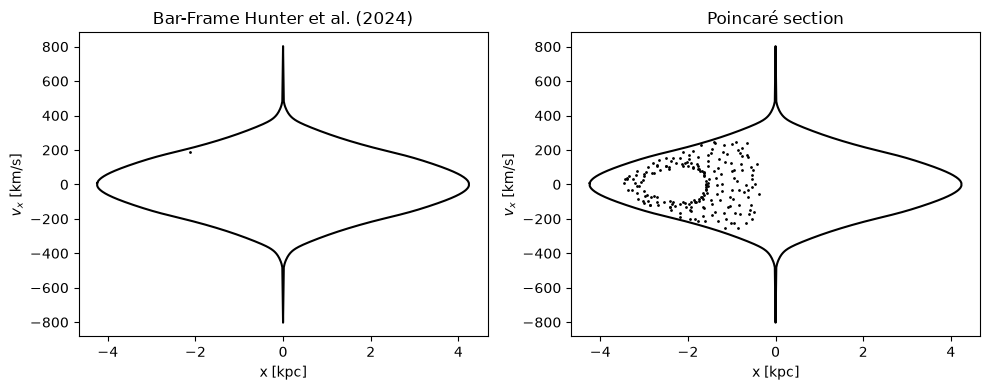

In [67]:
fig, axis = plt.subplots(1, 2, figsize=(10, 4))

axis[0].plot(xs_poly, vxs_poly, color="k")
axis[0].scatter(initconds[:, 0], initconds[:, 3], c="k", s=1)
axis[0].set(
    xlabel="x [kpc]",
    ylabel=r"$v_x$ [km/s]",
    title="Bar-Frame Hunter et al. (2024)"
)

axis[1].plot(xs_poly, vxs_poly, color="k")
axis[1].scatter(xcross, vxcross, s=1, color="k")
axis[1].set(
    xlabel="x [kpc]",
    ylabel=r"$v_x$ [km/s]",
    title="Poincaré section"
)

plt.tight_layout()
plt.show()

In [21]:
myorb=orbits[0]

In [ ]:
timestamps = np.linspace(0,time_integration,1000)

orbit_index = 0
x = orbits[orbit_index].x(timestamps)
y = orbits[orbit_index].y(timestamps)
vx = orbits[orbit_index].x(timestamps,der=1) - omega*y
vy = orbits[orbit_index].y(timestamps,der=1) + omega*x

# direct Jacobi check
Ej_cross = 0.5*(vx**2 + vy**2) + barframe.pot_eff(
    pot, omega, np.column_stack([x, y, np.zeros_like(x)]))

print("Ej error:", np.max(np.abs((Ej_cross - Ej)/Ej)))

Ej error: 0.0600107840376209


In [48]:
error=np.abs((Ej_cross - Ej)/Ej)

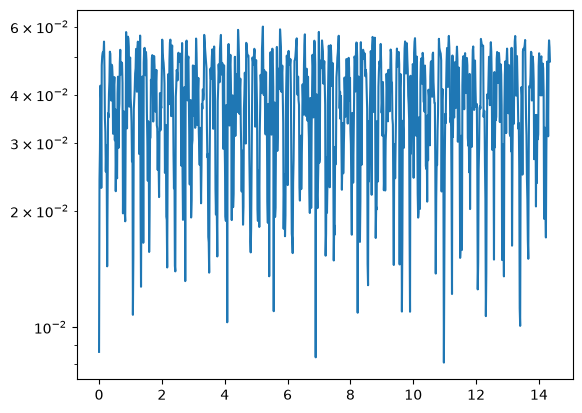

In [49]:
plt.plot(timestamps,error)
plt.yscale("log");